# North Atlantic Hurricane Intensity Since 1970

This notebook analyzes North Atlantic hurricane intensity using the NOAA IBTrACS hurricane track dataset. My part of the group project focuses on maximum wind speed, minimum pressure, strongest storms, and changes in intensity over time.

The main research question is:

**Have North Atlantic hurricanes become stronger over time since 1970?**

To answer this question, I use storm-level and year-level intensity metrics, including maximum sustained wind speed and minimum central pressure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load the NOAA IBTrACS hurricane dataset

I load the NOAA IBTrACS dataset directly from the online CSV file. This makes the notebook self-contained and reproducible because the dataset is accessed from within the notebook rather than manually downloaded.

In [9]:
url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/csv/ibtracs.ALL.list.v04r00.csv"

# The first row after the header contains units, so I skip it.
# I use the first 12 columns because they contain the storm ID, basin, time, location,
# maximum wind speed, and central pressure.
df = pd.read_csv(
    url,
    parse_dates=["ISO_TIME"],
    usecols=range(12),
    skiprows=[1],
    na_values=[" ", "", "NOT_NAMED"],
    keep_default_na=False
)

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))
print("Shape:", df.shape)

df.head()

/tmp/ipykernel_212/1981787323.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Number of rows: 716165
Number of columns: 12
Shape: (716165, 12)


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
0,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 03:00:00,NR,10.9000,80.3000,NaN,NaN
1,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 06:00:00,NR,10.8709,79.8265,NaN,NaN
2,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 09:00:00,NR,10.8431,79.3524,NaN,NaN
3,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 12:00:00,NR,10.8188,78.8772,NaN,NaN
4,1842298N11080,1842,1,NI,BB,NaN,1842-10-25 15:00:00,NR,10.8000,78.4000,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716165 entries, 0 to 716164
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       716165 non-null  object        
 1   SEASON    716165 non-null  int64         
 2   NUMBER    716165 non-null  int64         
 3   BASIN     716165 non-null  object        
 4   SUBBASIN  716165 non-null  object        
 5   NAME      390393 non-null  object        
 6   ISO_TIME  716165 non-null  datetime64[ns]
 7   NATURE    716165 non-null  object        
 8   LAT       716165 non-null  float64       
 9   LON       716165 non-null  float64       
 10  WMO_WIND  157570 non-null  float64       
 11  WMO_PRES  160275 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 65.6+ MB


## 2. Prepare North Atlantic intensity data since 1970

I rename the wind and pressure columns to shorter names. Then I filter the dataset to North Atlantic storms since 1970. Wind speed is measured in knots, and pressure is measured in millibars/hPa.

In [11]:
# Rename columns for easier analysis
df = df.rename(
    columns={
        "WMO_WIND": "WIND",
        "WMO_PRES": "PRES"
    }
)

# Convert intensity columns to numeric values
# Some rows may contain missing or non-numeric values, so errors are converted to NaN.
df["WIND"] = pd.to_numeric(df["WIND"], errors="coerce")
df["PRES"] = pd.to_numeric(df["PRES"], errors="coerce")

# Filter to North Atlantic storms since 1970
df_na = df[
    (df["BASIN"] == "NA") &
    (df["SEASON"] >= 1970)
].copy()

df_na = df_na.set_index("ISO_TIME").sort_index()

print("Number of North Atlantic datapoints since 1970:", len(df_na))
print("Number of unique North Atlantic storms since 1970:", df_na["SID"].nunique())

df_na.head()

Number of North Atlantic datapoints since 1970: 48154
Number of unique North Atlantic storms since 1970: 914


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1970-05-17 18:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.5000,-79.0000,25.0,NaN
1970-05-17 21:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.6475,-79.1400,NaN,NaN
1970-05-18 00:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.8000,-79.3000,25.0,NaN
1970-05-18 03:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,11.9575,-79.4925,NaN,NaN
1970-05-18 06:00:00,1970138N12281,1970,43,NA,CS,ALMA,TS,12.1000,-79.7000,25.0,NaN


## 3. Create storm-level intensity metrics

The raw IBTrACS data contain many observations for each storm. To analyze hurricane intensity, I summarize each storm into one row using its lifetime maximum wind speed and lifetime minimum pressure.

In [12]:
# Create one row per storm
storm_intensity = (
    df_na
    .groupby("SID")
    .agg(
        NAME=("NAME", "first"),
        SEASON=("SEASON", "max"),
        MAX_WIND=("WIND", "max"),
        MIN_PRESSURE=("PRES", "min"),
        OBSERVATIONS=("WIND", "size")
    )
    .reset_index()
)

# Remove storms with no wind data
storm_intensity = storm_intensity.dropna(subset=["MAX_WIND"])

print("Number of storms with wind data:", len(storm_intensity))
storm_intensity.head()

Number of storms with wind data: 893


,SID,NAME,SEASON,MAX_WIND,MIN_PRESSURE,OBSERVATIONS
0,1970138N12281,ALMA,1970,65.0,993.0,75
1,1970200N19277,BECKY,1970,55.0,1003.0,38
2,1970210N34285,None,1970,30.0,1008.0,33
3,1970212N18278,CELIA,1970,120.0,944.0,47
4,1970215N14342,None,1970,30.0,NaN,33


In [13]:
# Define hurricane category based on maximum sustained wind speed in knots
# Saffir-Simpson thresholds: Cat 1 = 64 kt, Cat 2 = 83 kt, Cat 3 = 96 kt,
# Cat 4 = 113 kt, Cat 5 = 137 kt.
def wind_category(wind):
    if pd.isna(wind):
        return np.nan
    elif wind >= 137:
        return "Category 5"
    elif wind >= 113:
        return "Category 4"
    elif wind >= 96:
        return "Category 3"
    elif wind >= 83:
        return "Category 2"
    elif wind >= 64:
        return "Category 1"
    else:
        return "Below Hurricane Strength"

storm_intensity["CATEGORY"] = storm_intensity["MAX_WIND"].apply(wind_category)
storm_intensity.head()

,SID,NAME,SEASON,MAX_WIND,MIN_PRESSURE,OBSERVATIONS,CATEGORY
0,1970138N12281,ALMA,1970,65.0,993.0,75,Category 1
1,1970200N19277,BECKY,1970,55.0,1003.0,38,Below Hurricane Strength
2,1970210N34285,None,1970,30.0,1008.0,33,Below Hurricane Strength
3,1970212N18278,CELIA,1970,120.0,944.0,47,Category 4
4,1970215N14342,None,1970,30.0,NaN,33,Below Hurricane Strength


## 4. Annual maximum wind speed

The first figure shows the strongest storm in each North Atlantic hurricane season based on maximum sustained wind speed. I also include a 5-year rolling average to make the long-term pattern easier to see.

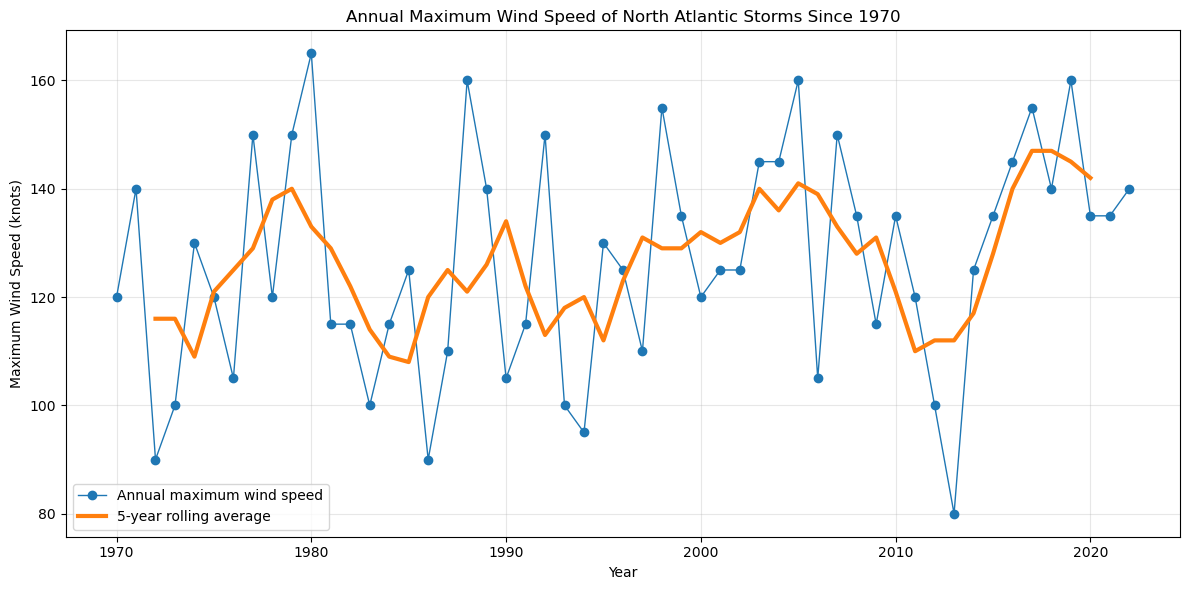

In [14]:
annual_max_wind = storm_intensity.groupby("SEASON")["MAX_WIND"].max()
annual_max_wind_rolling = annual_max_wind.rolling(window=5, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    annual_max_wind.index,
    annual_max_wind.values,
    marker="o",
    linewidth=1,
    label="Annual maximum wind speed"
)

ax.plot(
    annual_max_wind_rolling.index,
    annual_max_wind_rolling.values,
    linewidth=3,
    label="5-year rolling average"
)

ax.set_title("Annual Maximum Wind Speed of North Atlantic Storms Since 1970")
ax.set_xlabel("Year")
ax.set_ylabel("Maximum Wind Speed (knots)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** Figure 1 shows large year-to-year variability in the maximum wind speed of the strongest storm each season. The rolling average helps show whether the most intense storms have become stronger over time, while still making clear that individual hurricane seasons can vary greatly.

## 5. Annual minimum central pressure

Wind speed is one measure of hurricane intensity, but central pressure is another important measure. Lower central pressure usually indicates a stronger storm. This figure shows the lowest central pressure recorded in each North Atlantic season.

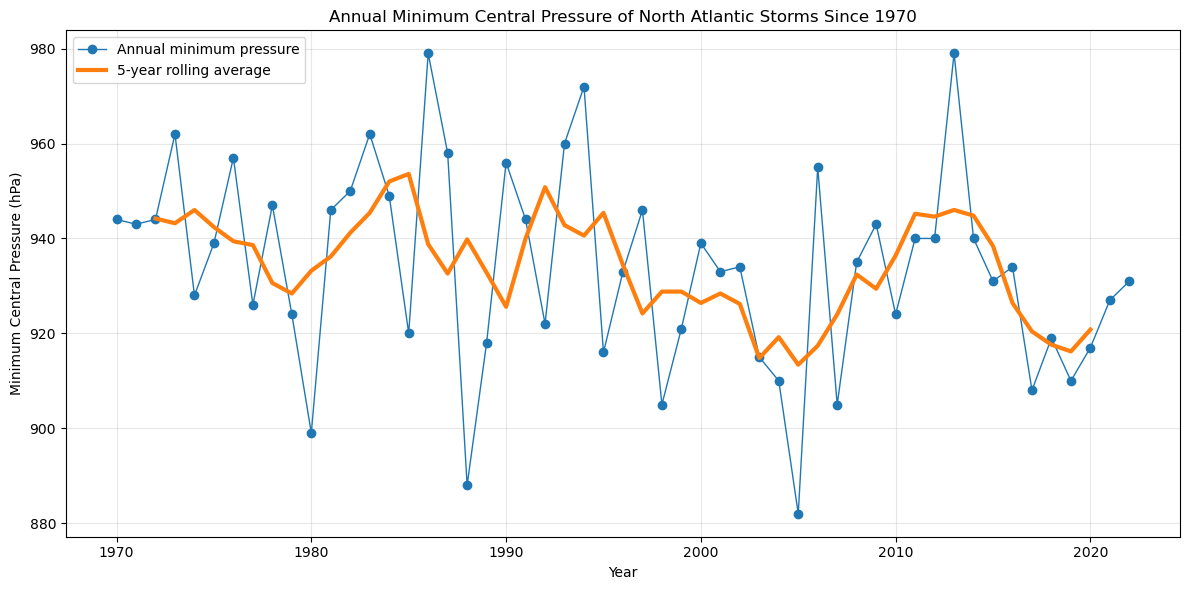

In [15]:
annual_min_pressure = storm_intensity.dropna(subset=["MIN_PRESSURE"]).groupby("SEASON")["MIN_PRESSURE"].min()
annual_min_pressure_rolling = annual_min_pressure.rolling(window=5, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    annual_min_pressure.index,
    annual_min_pressure.values,
    marker="o",
    linewidth=1,
    label="Annual minimum pressure"
)

ax.plot(
    annual_min_pressure_rolling.index,
    annual_min_pressure_rolling.values,
    linewidth=3,
    label="5-year rolling average"
)

ax.set_title("Annual Minimum Central Pressure of North Atlantic Storms Since 1970")
ax.set_xlabel("Year")
ax.set_ylabel("Minimum Central Pressure (hPa)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** Figure 2 provides a second view of storm intensity. Because lower pressure indicates stronger storms, unusually low values identify seasons with particularly intense hurricanes. Comparing this figure with wind speed helps check whether the intensity pattern is consistent across two different metrics.

## 6. Strongest storms by maximum wind speed

The next figure identifies the strongest North Atlantic storms in the dataset based on lifetime maximum wind speed. This helps show which storms stand out most clearly in the historical record since 1970.

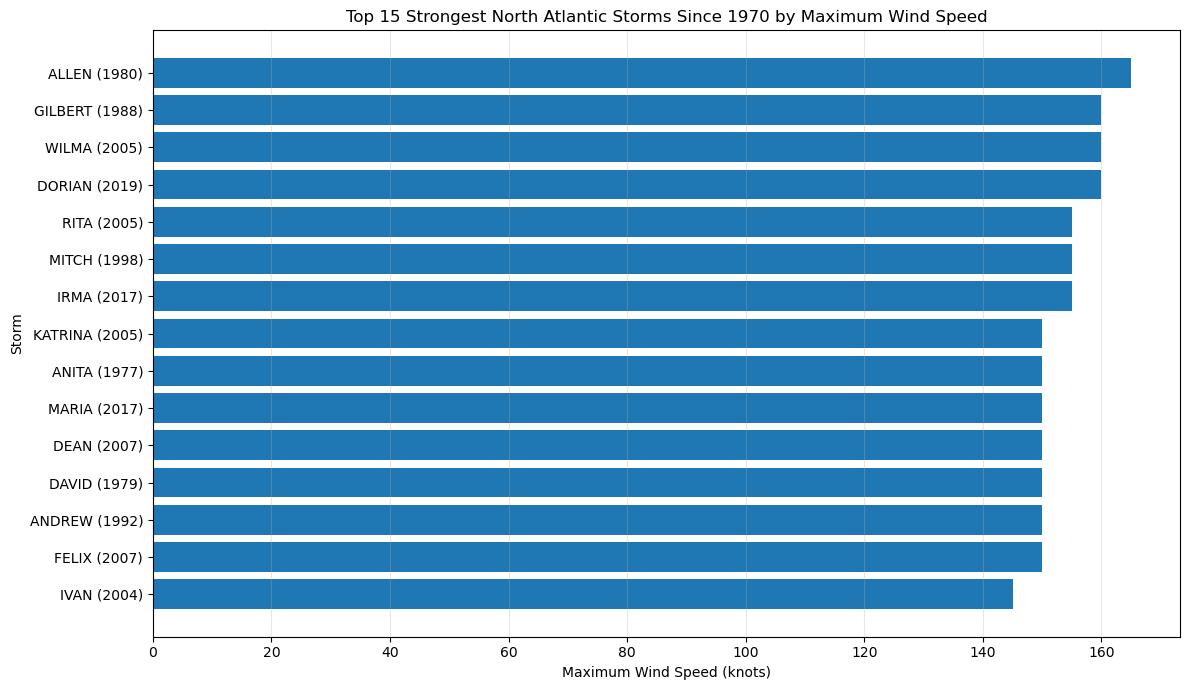

,NAME,SEASON,MAX_WIND,MIN_PRESSURE,CATEGORY
207,ALLEN,1980,165.0,899.0,Category 5
328,GILBERT,1988,160.0,888.0,Category 5
808,DORIAN,2019,160.0,910.0,Category 5
594,WILMA,2005,160.0,882.0,Category 5
465,MITCH,1998,155.0,905.0,Category 5
779,IRMA,2017,155.0,914.0,Category 5
587,RITA,2005,155.0,895.0,Category 5
616,FELIX,2007,150.0,929.0,Category 5
149,ANITA,1977,150.0,926.0,Category 5
614,DEAN,2007,150.0,905.0,Category 5


In [16]:
top_storms = (
    storm_intensity
    .sort_values("MAX_WIND", ascending=False)
    .head(15)
    .copy()
)

top_storms["LABEL"] = top_storms["NAME"].fillna("Unnamed") + " (" + top_storms["SEASON"].astype(str) + ")"

top_storms_plot = top_storms.sort_values("MAX_WIND")

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(top_storms_plot["LABEL"], top_storms_plot["MAX_WIND"])

ax.set_title("Top 15 Strongest North Atlantic Storms Since 1970 by Maximum Wind Speed")
ax.set_xlabel("Maximum Wind Speed (knots)")
ax.set_ylabel("Storm")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

top_storms[["NAME", "SEASON", "MAX_WIND", "MIN_PRESSURE", "CATEGORY"]]

**Interpretation:** Figure 3 ranks the strongest storms by maximum wind speed. This figure is useful because it connects the time-series analysis to real storms and shows whether the strongest storms are concentrated in particular decades or spread across the full period.

## 7. Intensity distribution by decade

Looking only at the strongest storm each year can hide changes in the broader distribution of storm intensity. Here I compare the distribution of storm-level maximum wind speed by decade.

/tmp/ipykernel_212/190396441.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


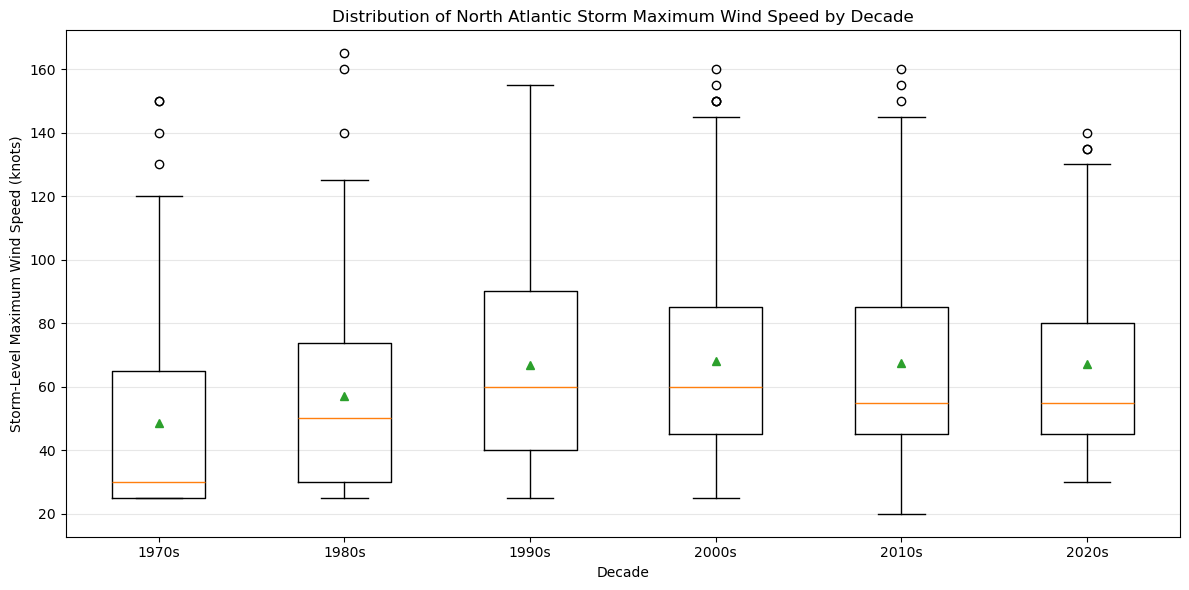

In [17]:
storm_intensity["DECADE"] = (storm_intensity["SEASON"] // 10) * 10

# Keep complete decades from the 1970s through the 2020s.
decade_order = sorted(storm_intensity["DECADE"].dropna().unique())
wind_by_decade = [
    storm_intensity.loc[storm_intensity["DECADE"] == decade, "MAX_WIND"].dropna()
    for decade in decade_order
]

fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(
    wind_by_decade,
    labels=[str(int(decade)) + "s" for decade in decade_order],
    showmeans=True
)

ax.set_title("Distribution of North Atlantic Storm Maximum Wind Speed by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Storm-Level Maximum Wind Speed (knots)")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** Figure 4 compares the full distribution of maximum wind speed across decades. The boxes show typical storm intensity, while the outliers show unusually strong storms. This is a more complete view than only comparing the single strongest storm in each year.

## 8. Hurricane category distribution by decade

Finally, I classify each storm by its lifetime maximum wind speed and compare the number of storms in each category by decade. This helps evaluate whether major hurricanes, especially Category 3–5 storms, have become more common.

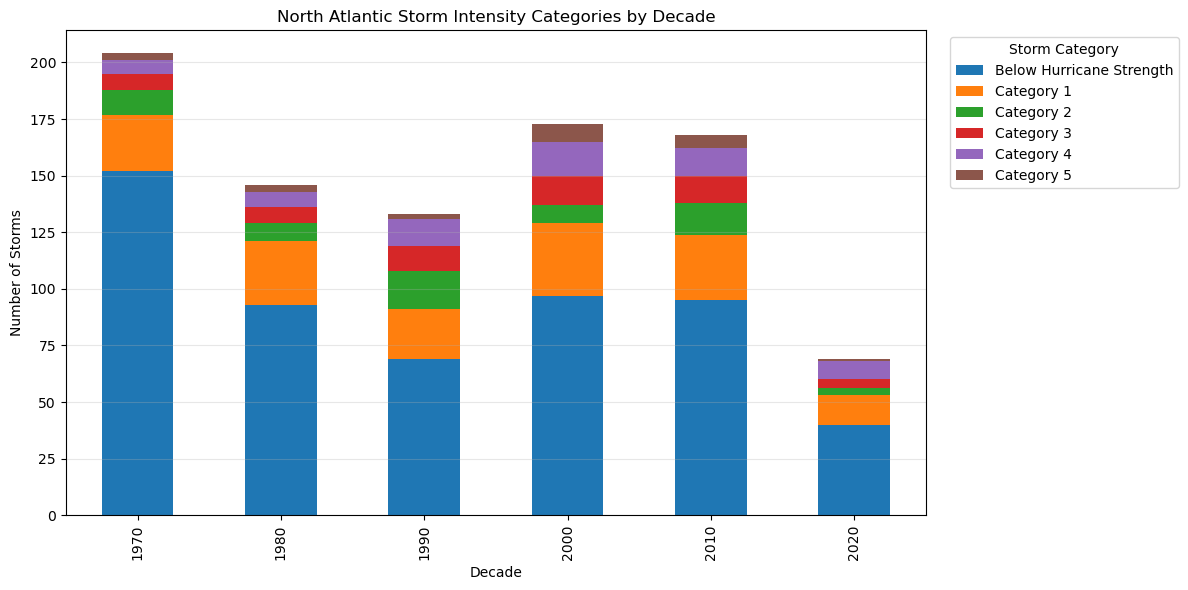

CATEGORY,Below Hurricane Strength,Category 1,Category 2,Category 3,Category 4,Category 5
DECADE,,,,,,
1970,152,25,11,7,6,3
1980,93,28,8,7,7,3
1990,69,22,17,11,12,2
2000,97,32,8,13,15,8
2010,95,29,14,12,12,6
2020,40,13,3,4,8,1


In [18]:
category_order = [
    "Below Hurricane Strength",
    "Category 1",
    "Category 2",
    "Category 3",
    "Category 4",
    "Category 5"
]

category_by_decade = (
    storm_intensity
    .groupby(["DECADE", "CATEGORY"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=category_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))

category_by_decade.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("North Atlantic Storm Intensity Categories by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Number of Storms")
ax.legend(title="Storm Category", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

category_by_decade

**Interpretation:** Figure 5 shows how storm intensity categories vary by decade. The most important comparison is the number of Category 3, 4, and 5 storms, because these are major hurricanes. This figure should be interpreted together with the group member's activity notebook, since an increase in the number of intense storms could partly reflect an increase in the total number of storms observed.

## 9. Simple trend statistics

As a final check, I calculate simple linear trends for the annual maximum wind speed and annual minimum pressure time series. These are descriptive statistics, not a full climate attribution analysis.

In [19]:
# Trend in annual maximum wind speed
wind_years = annual_max_wind.dropna().index.values
wind_values = annual_max_wind.dropna().values
wind_slope, wind_intercept = np.polyfit(wind_years, wind_values, 1)
wind_corr = np.corrcoef(wind_years, wind_values)[0, 1]

# Trend in annual minimum pressure
pressure_years = annual_min_pressure.dropna().index.values
pressure_values = annual_min_pressure.dropna().values
pressure_slope, pressure_intercept = np.polyfit(pressure_years, pressure_values, 1)
pressure_corr = np.corrcoef(pressure_years, pressure_values)[0, 1]

trend_summary = pd.DataFrame({
    "Metric": ["Annual maximum wind speed", "Annual minimum pressure"],
    "Slope per year": [wind_slope, pressure_slope],
    "Correlation with year": [wind_corr, pressure_corr]
})

trend_summary

,Metric,Slope per year,Correlation with year
0,Annual maximum wind speed,0.324141,0.241519
1,Annual minimum pressure,-0.360748,-0.263678


**Interpretation:** The slope values summarize the direction of change over time. A positive slope for wind speed would suggest increasing annual peak intensity, while a negative slope for pressure would suggest stronger storms because lower pressure indicates greater intensity. However, these simple trends should be interpreted carefully because hurricane intensity has high natural variability and the observing system has changed over time.

## Conclusion

This notebook investigated North Atlantic hurricane intensity since 1970 using the NOAA IBTrACS dataset. The analysis used maximum wind speed and minimum central pressure to identify the strongest storms, compare annual intensity extremes, and examine how storm intensity distributions vary by decade.

Overall, the figures show that North Atlantic hurricane intensity has strong year-to-year variability, with certain years and storms standing out as especially intense. The wind speed, pressure, and category analyses together provide a clearer picture of intensity than any single metric alone.

## Limitations

This analysis is descriptive and does not prove that climate change caused any observed trend. The IBTrACS record also reflects changes in satellite observations, aircraft reconnaissance, measurement practices, and storm detection over time. A more advanced analysis could compare these results with sea-surface temperature, climate model output, or environmental variables such as wind shear and ocean heat content.